In [ ]:
# Install kagglehub if it's not already in the Colab environment
!pip install -q kagglehub

import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
from PIL import Image
import copy

# Best Practice: Explicitly set device and enable cudnn benchmark for faster GPU training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True
print(f"✅ Training on device: {device}")

✅ Training on device: cpu


In [ ]:
# 1. Download the Dataset
print("Downloading dataset...")
dataset_path = kagglehub.dataset_download("serenaraju/yawn-eye-dataset-new")
print("Dataset downloaded to:", dataset_path)

# Look for the exact folder containing the class subdirectories
base_dir = dataset_path
for root, dirs, files in os.walk(dataset_path):
    if 'Open' in dirs and 'Closed' in dirs:
        base_dir = root
        break
print(f"✅ Using image directory: {base_dir}")

100%|██████████| 161M/161M [00:01<00:00, 126MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/serenaraju/yawn-eye-dataset-new/versions/1
✅ Using image directory: /root/.cache/kagglehub/datasets/serenaraju/yawn-eye-dataset-new/versions/1/dataset_new/train


In [ ]:
# Best Practice: Base dataset yields raw PIL images so we can apply different transforms later
class RawEyeDataset(Dataset):
    def __init__(self, root_dir):
        self.image_paths = []
        self.labels = []
        class_mapping = {'Closed': 0, 'Open': 1}

        for class_name, label in class_mapping.items():
            class_dir = os.path.join(root_dir, class_name)
            if not os.path.exists(class_dir):
                class_dir = os.path.join(root_dir, class_name.lower())

            if os.path.exists(class_dir):
                for img_name in os.listdir(class_dir):
                    if img_name.endswith(('.jpg', '.jpeg', '.png')):
                        self.image_paths.append(os.path.join(class_dir, img_name))
                        self.labels.append(label)

    def __len__(self): return len(self.image_paths)
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        return image, self.labels[idx]

# Wrapper to apply specific transforms to train/val subsets
class TransformedDataset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
    def __len__(self): return len(self.subset)
    def __getitem__(self, idx):
        x, y = self.subset[idx]
        if self.transform: x = self.transform(x)
        return x, y

# Best Practice: Data Augmentation for training
train_transform = transforms.Compose([
    # 1. Add ColorJitter BEFORE Grayscale to simulate different colored lights & intensities
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),

    # 2. Convert to Grayscale (Keep existing pipeline)
    transforms.Grayscale(num_output_channels=1),

    # 3. Spatial Transformations
    transforms.Resize((24, 24)),
    transforms.RandomHorizontalFlip(p=0.5), # Augmentation: Flip
    transforms.RandomRotation(degrees=15),  # Augmentation: Rotate

    # 4. Tensor Conversion and Normalization
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]) # Best Practice: Normalize data
])

# Validation relies strictly on standardizing the image (NO JITTER HERE)
val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((24, 24)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# Load and split
full_dataset = RawEyeDataset(root_dir=base_dir)
print(f"Found {len(full_dataset)} eye images.")

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
indices = torch.randperm(len(full_dataset)).tolist()

train_subset = Subset(full_dataset, indices[:train_size])
val_subset = Subset(full_dataset, indices[train_size:])

train_dataset = TransformedDataset(train_subset, transform=train_transform)
val_dataset = TransformedDataset(val_subset, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)

Found 1234 eye images.


In [ ]:
# Best Practice: Base dataset yields raw PIL images so we can apply different transforms later
class RawEyeDataset(Dataset):
    def __init__(self, root_dir):
        self.image_paths = []
        self.labels = []
        class_mapping = {'Closed': 0, 'Open': 1}

        for class_name, label in class_mapping.items():
            class_dir = os.path.join(root_dir, class_name)
            if not os.path.exists(class_dir):
                class_dir = os.path.join(root_dir, class_name.lower())

            if os.path.exists(class_dir):
                for img_name in os.listdir(class_dir):
                    if img_name.endswith(('.jpg', '.jpeg', '.png')):
                        self.image_paths.append(os.path.join(class_dir, img_name))
                        self.labels.append(label)

    def __len__(self): return len(self.image_paths)
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        return image, self.labels[idx]

# Wrapper to apply specific transforms to train/val subsets
class TransformedDataset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
    def __len__(self): return len(self.subset)
    def __getitem__(self, idx):
        x, y = self.subset[idx]
        if self.transform: x = self.transform(x)
        return x, y

# Best Practice: Data Augmentation for training
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((24, 24)),
    transforms.RandomHorizontalFlip(p=0.5), # Augmentation: Flip
    transforms.RandomRotation(degrees=15),  # Augmentation: Rotate
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]) # Best Practice: Normalize data
])

# Validation relies strictly on standardizing the image
val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((24, 24)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# Load and split
full_dataset = RawEyeDataset(root_dir=base_dir)
print(f"Found {len(full_dataset)} eye images.")

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
indices = torch.randperm(len(full_dataset)).tolist()

train_subset = Subset(full_dataset, indices[:train_size])
val_subset = Subset(full_dataset, indices[train_size:])

train_dataset = TransformedDataset(train_subset, transform=train_transform)
val_dataset = TransformedDataset(val_subset, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)

Found 1234 eye images.


In [ ]:
class ImprovedEyeClassifier(nn.Module):
    def __init__(self):
        super(ImprovedEyeClassifier, self).__init__()
        # Input: 1 x 24 x 24
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32) # Stabilizes learning
        self.pool1 = nn.MaxPool2d(2, 2) # Reduces dimensions to 12x12

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2) # Reduces dimensions to 6x6

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2, 2) # Reduces dimensions to 3x3

        # Flattened size: 128 channels * 3 * 3 = 1152
        self.fc1 = nn.Linear(128 * 3 * 3, 128)
        self.dropout = nn.Dropout(0.5) # Prevents overfitting
        self.fc2 = nn.Linear(128, 2)

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))
        x = x.view(-1, 128 * 3 * 3)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = ImprovedEyeClassifier().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Best Practice: Learning rate scheduler (decreases LR if val_loss stops improving)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

In [ ]:
epochs = 20
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_loss = float('inf')
best_model_weights = copy.deepcopy(model.state_dict())

os.makedirs('models', exist_ok=True)

for epoch in range(epochs):
    # --- Training Phase ---
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = correct_train / total_train

    # --- Validation Phase ---
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = val_loss / total_val
    epoch_val_acc = correct_val / total_val

    # Save metrics for plotting
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)

    # Step the scheduler
    scheduler.step(epoch_val_loss)

    # Best Practice: Save only the best model
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_model_weights = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), 'models/best_model.pth')
        saved_flag = "💾 [Saved Best Model]"
    else:
        saved_flag = ""

    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f} | Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f} {saved_flag}")

# Load the best weights back into the model at the end
model.load_state_dict(best_model_weights)
print("Training complete! Best model weights loaded and saved to 'models/best_model.pth'.")

Epoch [1/20] | Train Loss: 0.4545 Acc: 0.7791 | Val Loss: 0.7589 Acc: 0.4980 💾 [Saved Best Model]
Epoch [2/20] | Train Loss: 0.1641 Acc: 0.9352 | Val Loss: 0.8992 Acc: 0.5466 
Epoch [3/20] | Train Loss: 0.1339 Acc: 0.9433 | Val Loss: 0.1871 Acc: 0.9190 💾 [Saved Best Model]
Epoch [4/20] | Train Loss: 0.0987 Acc: 0.9635 | Val Loss: 0.0725 Acc: 0.9717 💾 [Saved Best Model]
Epoch [5/20] | Train Loss: 0.0667 Acc: 0.9757 | Val Loss: 0.0605 Acc: 0.9757 💾 [Saved Best Model]
Epoch [6/20] | Train Loss: 0.0695 Acc: 0.9696 | Val Loss: 0.0446 Acc: 0.9879 💾 [Saved Best Model]
Epoch [7/20] | Train Loss: 0.0548 Acc: 0.9807 | Val Loss: 0.0402 Acc: 0.9879 💾 [Saved Best Model]
Epoch [8/20] | Train Loss: 0.0399 Acc: 0.9889 | Val Loss: 0.0253 Acc: 0.9960 💾 [Saved Best Model]
Epoch [9/20] | Train Loss: 0.0386 Acc: 0.9848 | Val Loss: 0.0586 Acc: 0.9757 
Epoch [10/20] | Train Loss: 0.0426 Acc: 0.9868 | Val Loss: 0.0347 Acc: 0.9879 
Epoch [11/20] | Train Loss: 0.0276 Acc: 0.9899 | Val Loss: 0.0457 Acc: 0.9838 


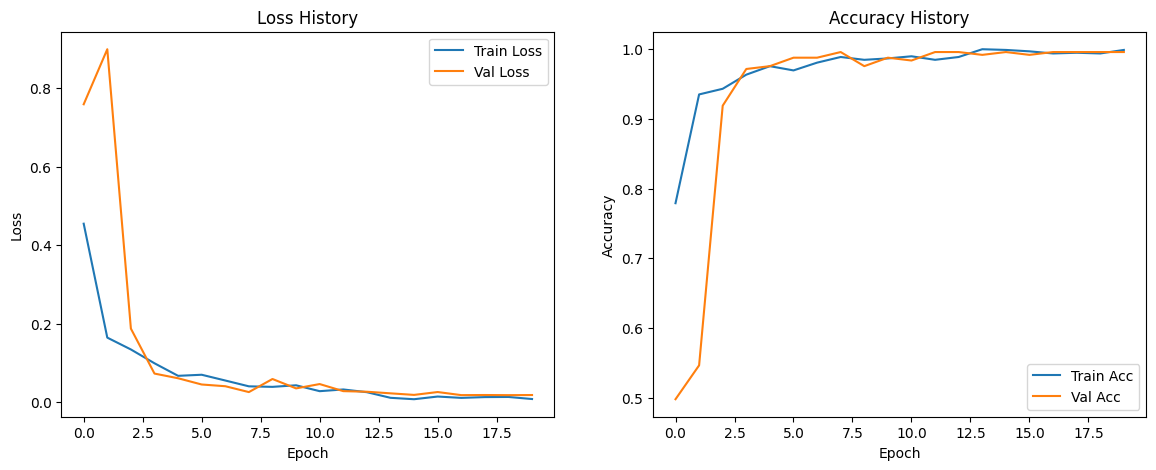


--- Classification Report ---
              precision    recall  f1-score   support

  Closed (0)       1.00      0.99      1.00       123
    Open (1)       0.99      1.00      1.00       124

    accuracy                           1.00       247
   macro avg       1.00      1.00      1.00       247
weighted avg       1.00      1.00      1.00       247



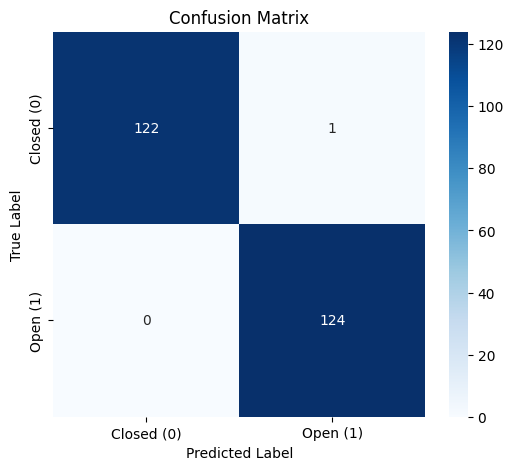

In [ ]:
# 1. Plot Learning Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history['train_loss'], label='Train Loss')
ax1.plot(history['val_loss'], label='Val Loss')
ax1.set_title('Loss History')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(history['train_acc'], label='Train Acc')
ax2.plot(history['val_acc'], label='Val Acc')
ax2.set_title('Accuracy History')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.show()

# 2. Generate Predictions for the Report
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# 3. Print Classification Report
classes = ['Closed (0)', 'Open (1)']
print("\n--- Classification Report ---")
print(classification_report(all_labels, all_preds, target_names=classes))

# 4. Plot Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
# Install wkhtmltopdf, a dependency for pdfkit to convert HTML to PDF
!sudo apt-get update
!sudo apt-get install wkhtmltopdf

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [87.4 kB]
Get:7 https://cli.github.com/packages stable/main amd64 Packages [357 B]
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,855 kB]
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease [24.6 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [6,669 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Ge

In [ ]:
import os
import pdfkit
from PyPDF2 import PdfMerger # This import is not used but kept as per original
from google.colab import files, drive

# Mount Google Drive if it's not already mounted
if not os.path.exists('/content/gdrive/MyDrive'):
    drive.mount('/content/gdrive')
    print("Google Drive mounted.")
else:
    print("Google Drive already mounted.")

# Define paths for the source notebook, intermediate HTML, and final PDF
notebook_source_path = '/content/gdrive/MyDrive/AI535/dl_final_project.ipynb'
input_html = '/content/gdrive/MyDrive/AI535/dl_final_project.html'
output_pdf = '/content/gdrive/MyDrive/AI535/dl_final_output.pdf'

# Create the directory if it doesn't exist for the output files
os.makedirs(os.path.dirname(notebook_source_path), exist_ok=True)

print(f"Attempting to convert notebook from: {notebook_source_path}")

# Check if the notebook file exists before attempting conversion
if not os.path.exists(notebook_source_path):
    print(f"ERROR: The notebook file does not exist at '{notebook_source_path}'.")
    print("Please ensure your current notebook is saved to this exact path in Google Drive.")
    print("You might need to go to File -> Save a copy in Drive and specify the path: /content/gdrive/MyDrive/AI535/dl_final_project.ipynb")
else:
    print(f"Notebook found at '{notebook_source_path}'. Proceeding with conversion to HTML.")
    # Convert the notebook to HTML
    # Use --output-dir and --output to explicitly control the output path and filename
    !jupyter nbconvert --to html "{notebook_source_path}" --output-dir "{os.path.dirname(input_html)}" --output "{os.path.basename(input_html)}"

    # Check if the HTML file was successfully created
    if os.path.exists(input_html):
        print(f"HTML file created successfully at: {input_html}")
        # Convert HTML to PDF
        try:
            pdfkit.from_file(input_html, output_pdf)
            print(f"PDF created successfully at: {output_pdf}")
            # Download the generated PDF
            files.download(output_pdf)
        except Exception as e:
            print(f"Error during PDF conversion: {e}")
            print("Please ensure wkhtmltopdf is installed correctly if you encounter issues. Sometimes it requires additional system packages.")
    else:
        print(f"ERROR: HTML file was not created by nbconvert. This might be due to an issue with the conversion or the input .ipynb file.")
        print("Please check the nbconvert output above for any additional error messages.")
